# import packages

In [85]:
import matplotlib.pyplot as plt 
import numpy as np
import pandas as pd 
import glob
import os

# set working directory

In [86]:
data_dir = r"C:/Users/l_v_v/Documents/GitHub/time_series_curuai/datasets/Parameters Time series/merged_df"

# standard plotting functions

In [87]:
# Configure matplotlib visualization parameters for consistency across all plots
plt.rcParams['font.size'] = 11  # Base font size
plt.rcParams['axes.labelsize'] = 11  # Axis label font size
plt.rcParams['axes.titlesize'] = 12  # Plot title font size
plt.rcParams['xtick.labelsize'] = 12  # X-axis tick label size
plt.rcParams['ytick.labelsize'] = 12  # Y-axis tick label size
plt.rcParams['legend.fontsize'] = 11  # Legend font size

In [ ]:
def prepare_time_series_plot(paths_var, paths_trend, dict_var, data_dir, color_palette=None):
    """Read paired time-series and trend CSVs and plot them efficiently.

    Parameters
    - paths_var: list of CSV filepaths containing time series (must contain 'time_start' and variables)
    - paths_trend: list of CSV filepaths with trend info; must contain a 'variable' column and a 'trend' column
    - dict_var: mapping variable -> {'title':..., 'label':...}
    - data_dir: base directory (used only for path context)
    - color_palette: optional list of colors for water periods
    """
    if color_palette is None:
        color_palette = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

    for p_var, p_trend in zip(paths_var, paths_trend):
        df = pd.read_csv(p_var, parse_dates=['time_start']).sort_values('time_start')

        # load trends robustly
        try:
            df_trend = pd.read_csv(p_trend)
        except Exception:
            df_trend = pd.read_csv(p_trend, encoding='utf-8', engine='python')

        if 'Unnamed: 0' in df_trend.columns:
            df_trend = df_trend.drop(columns=['Unnamed: 0'])
        if 'variable' in df_trend.columns:
            df_trend = df_trend.set_index('variable')

        axes = df_trend.index.tolist()

        fig, axs = plt.subplots(len(axes), 1, figsize=(12, 3 * max(1, len(axes))), squeeze=False)

        for i, var in enumerate(axes):
            ax = axs[i, 0]

            if var not in df.columns:
                ax.text(0.5, 0.5, f"{var} not in {os.path.basename(p_var)}", ha='center')
                continue


            if ("anthropogenic_km2" in var) or ("natural_km2" in var):
                drop_duplicates = df.drop_duplicates(subset=[var])
                series = drop_duplicates[var]
                x = drop_duplicates['time_start']
                ax.plot(x, series, color='gray', linestyle='-.', linewidth=1, alpha=0.6)
                ax.plot(x, series, marker='o', linestyle='none', markersize=6, color='#9467bd', alpha=0.8, label="Yearly Estimates")
                # linear fit (use ordinal x)
                x_ord = x.map(pd.Timestamp.toordinal)
                valid = series.notna() & x_ord.notna()
                if valid.sum() > 1:
                    m, b = np.polyfit(x_ord[valid], series[valid], 1)
                    ax.plot(x, m * x_ord + b, color='black', linestyle='--', linewidth=1)
                else:
                    m = b = np.nan

            else:
                series = df[var]
                x = df['time_start']
                ax.plot(x, series, color='gray', linestyle='-.', linewidth=1, alpha=0.6)

                # linear fit (use ordinal x)
                x_ord = x.map(pd.Timestamp.toordinal)
                valid = series.notna() & x_ord.notna()
                if valid.sum() > 1:
                    m, b = np.polyfit(x_ord[valid], series[valid], 1)
                    ax.plot(x, m * x_ord + b, color='black', linestyle='--', linewidth=1)
                else:
                    m = b = np.nan

                # water periods plotting
                if 'water_period' in df.columns:
                    water_periods = sorted(df['water_period'].dropna().unique())
                    colors = {period: color_palette[i % len(color_palette)] for i, period in enumerate(water_periods)}
                    for wp in water_periods:
                        sub = df[df['water_period'] == wp]
                        ax.plot(sub['time_start'], sub[var], marker='o', linestyle='none', markersize=6, color=colors[wp], alpha=0.8, label=str(wp))

            ax.set_xlabel('Date')
            ax.set_ylabel(dict_var.get(var, {}).get('label', var))
            # ax.set_title(dict_var.get(var, {}).get('title', var) + ' vs Time')

            # trend annotation if available
            trend_text = ''
            try:
                trend_text = df_trend.loc[var, 'trend']
            except Exception:
                trend_text = ''

            if not np.isnan(m):
                ax.annotate(f"y = {m:.3f}x + {b:.3f}\n{trend_text}\nn = {int(series.count())}", xy=(0.75, 1.01), xycoords='axes fraction')
            ax.legend(loc='')

        plt.tight_layout()
        sv_path = os.path.join(f"{os.path.dirname(p_trend)}", f"ts_{os.path.basename(p_var).split('_')[-1].replace('.csv', '.jpeg')}")
        plt.savefig(sv_path, dpi=350)
        plt.show()
        plt.close(fig)


In [89]:
dict_var = {
    "TSS_mean":{"title": "TSS", 'label': "TSS (mg/L)"},
    "area_km2": {"title": "Water Surface Area", 'label': "Area (km$^2$)"},
    "precipitation": {"title": "Precipitation", 'label': "Accumulated Precipitation\n(total mm/Hidrological Period)"},
    'u_wind': {"title": "Eastward Wind Speed", 'label': "Eastward Mean Wind Speed\n(m/s)"},
    "v_wind": {"title": "Northward Wind Speed", 'label': "Northward Mean Wind Speed\n(m/s)"},
    'anthropogenic_km2': {"title": "Anthropic Area", 'label': "Anthropic Area (km²)"},
    'natural_km2': {"title": "Natural Area", 'label': "Natural Area (km²)"},
    "mean_discharge": {"title": "Discharge", 'label': "Mean Discharge (m$^3$/s)"}
}

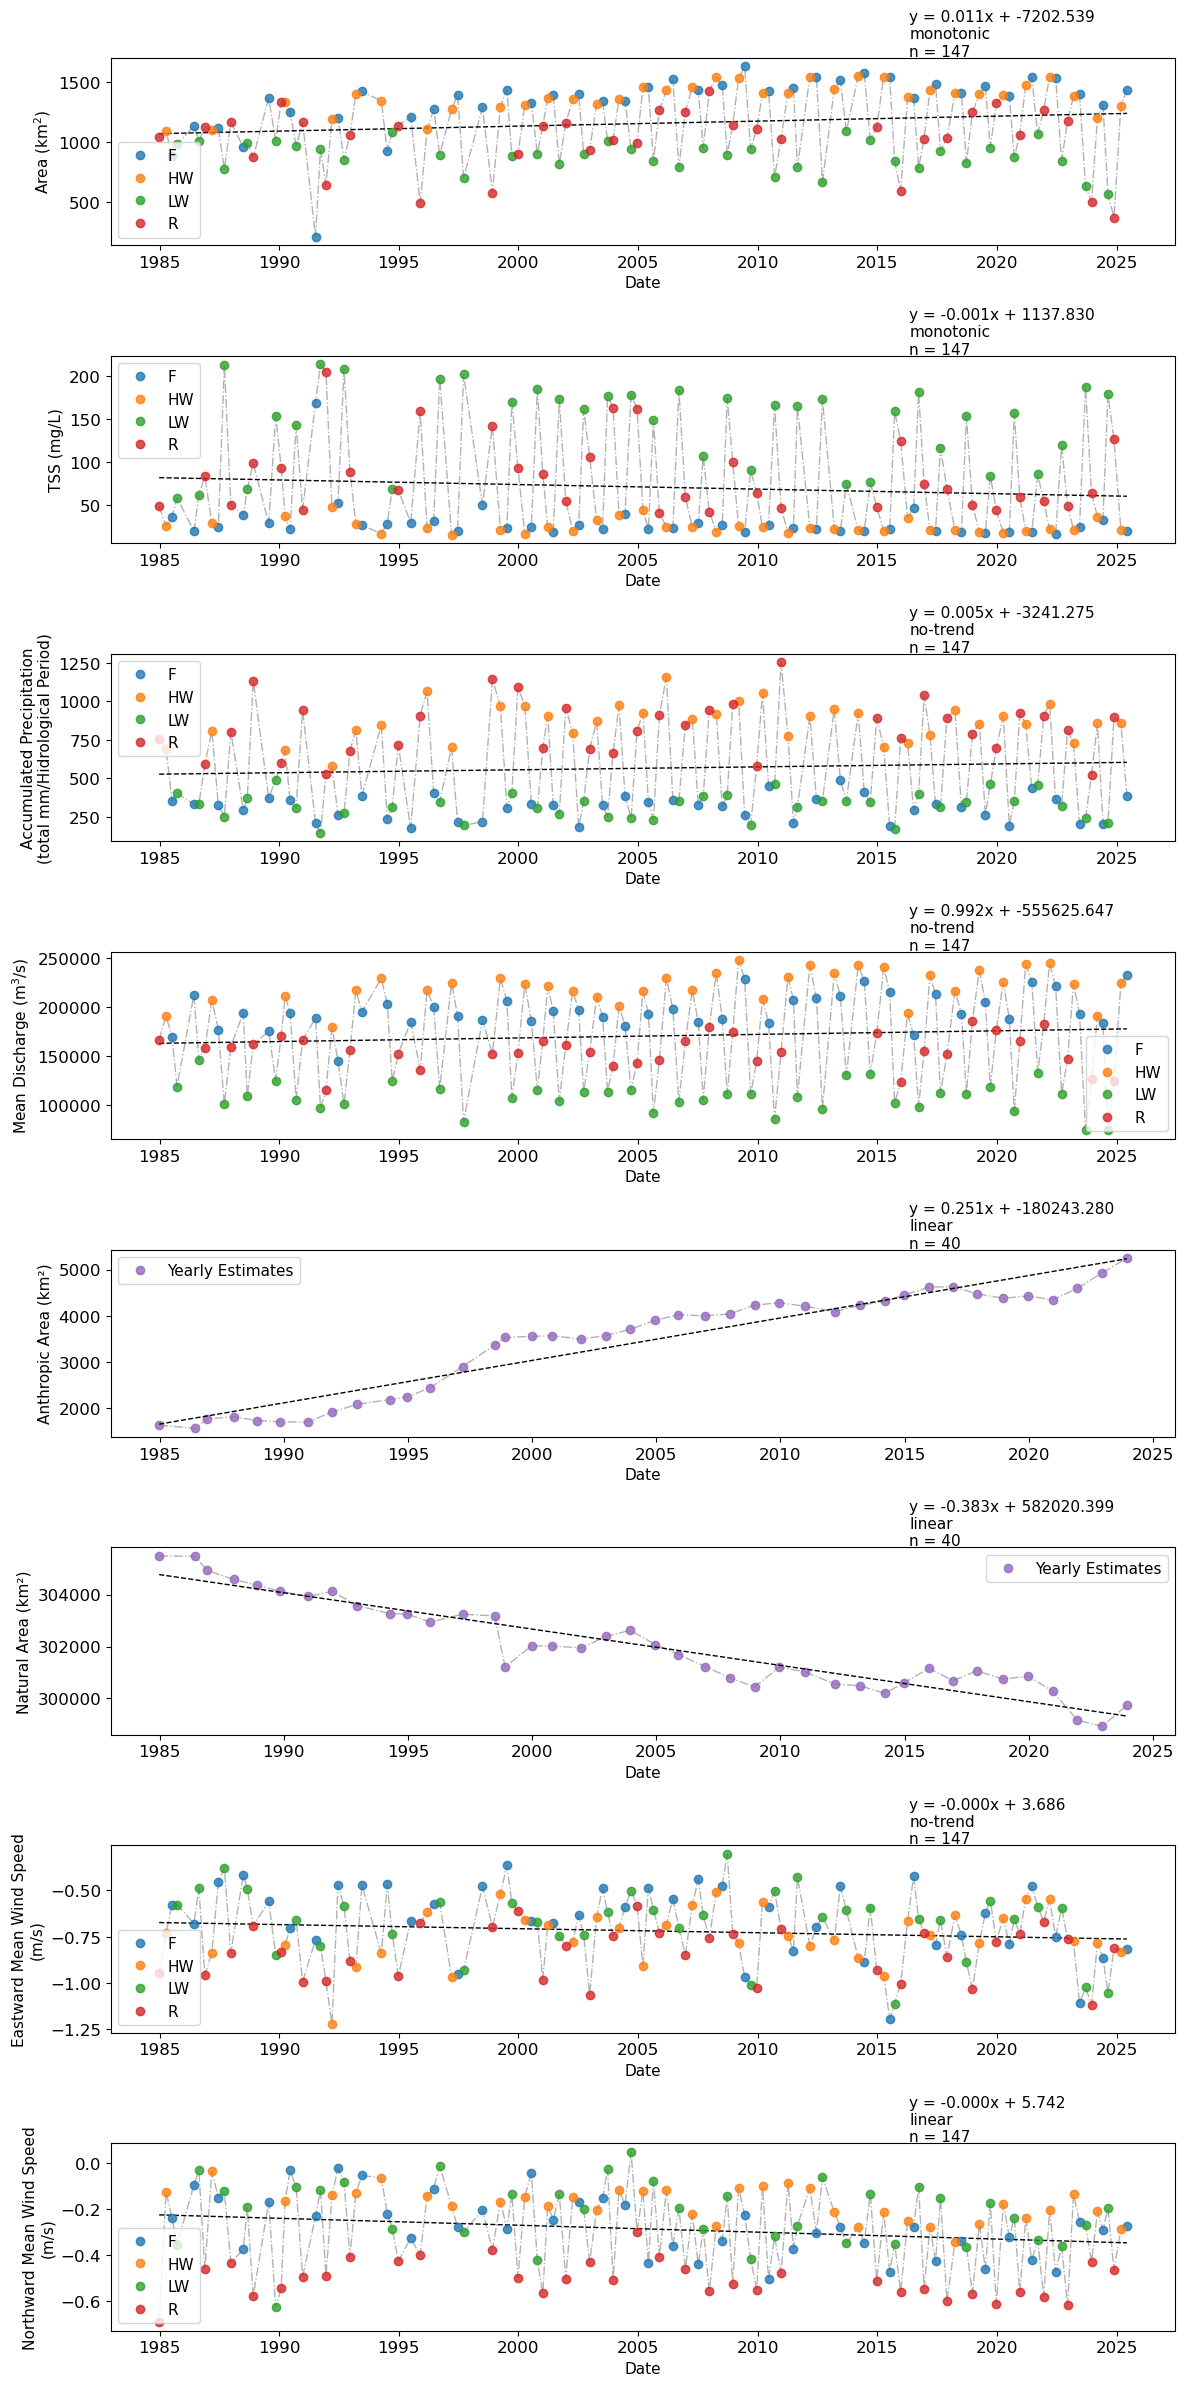

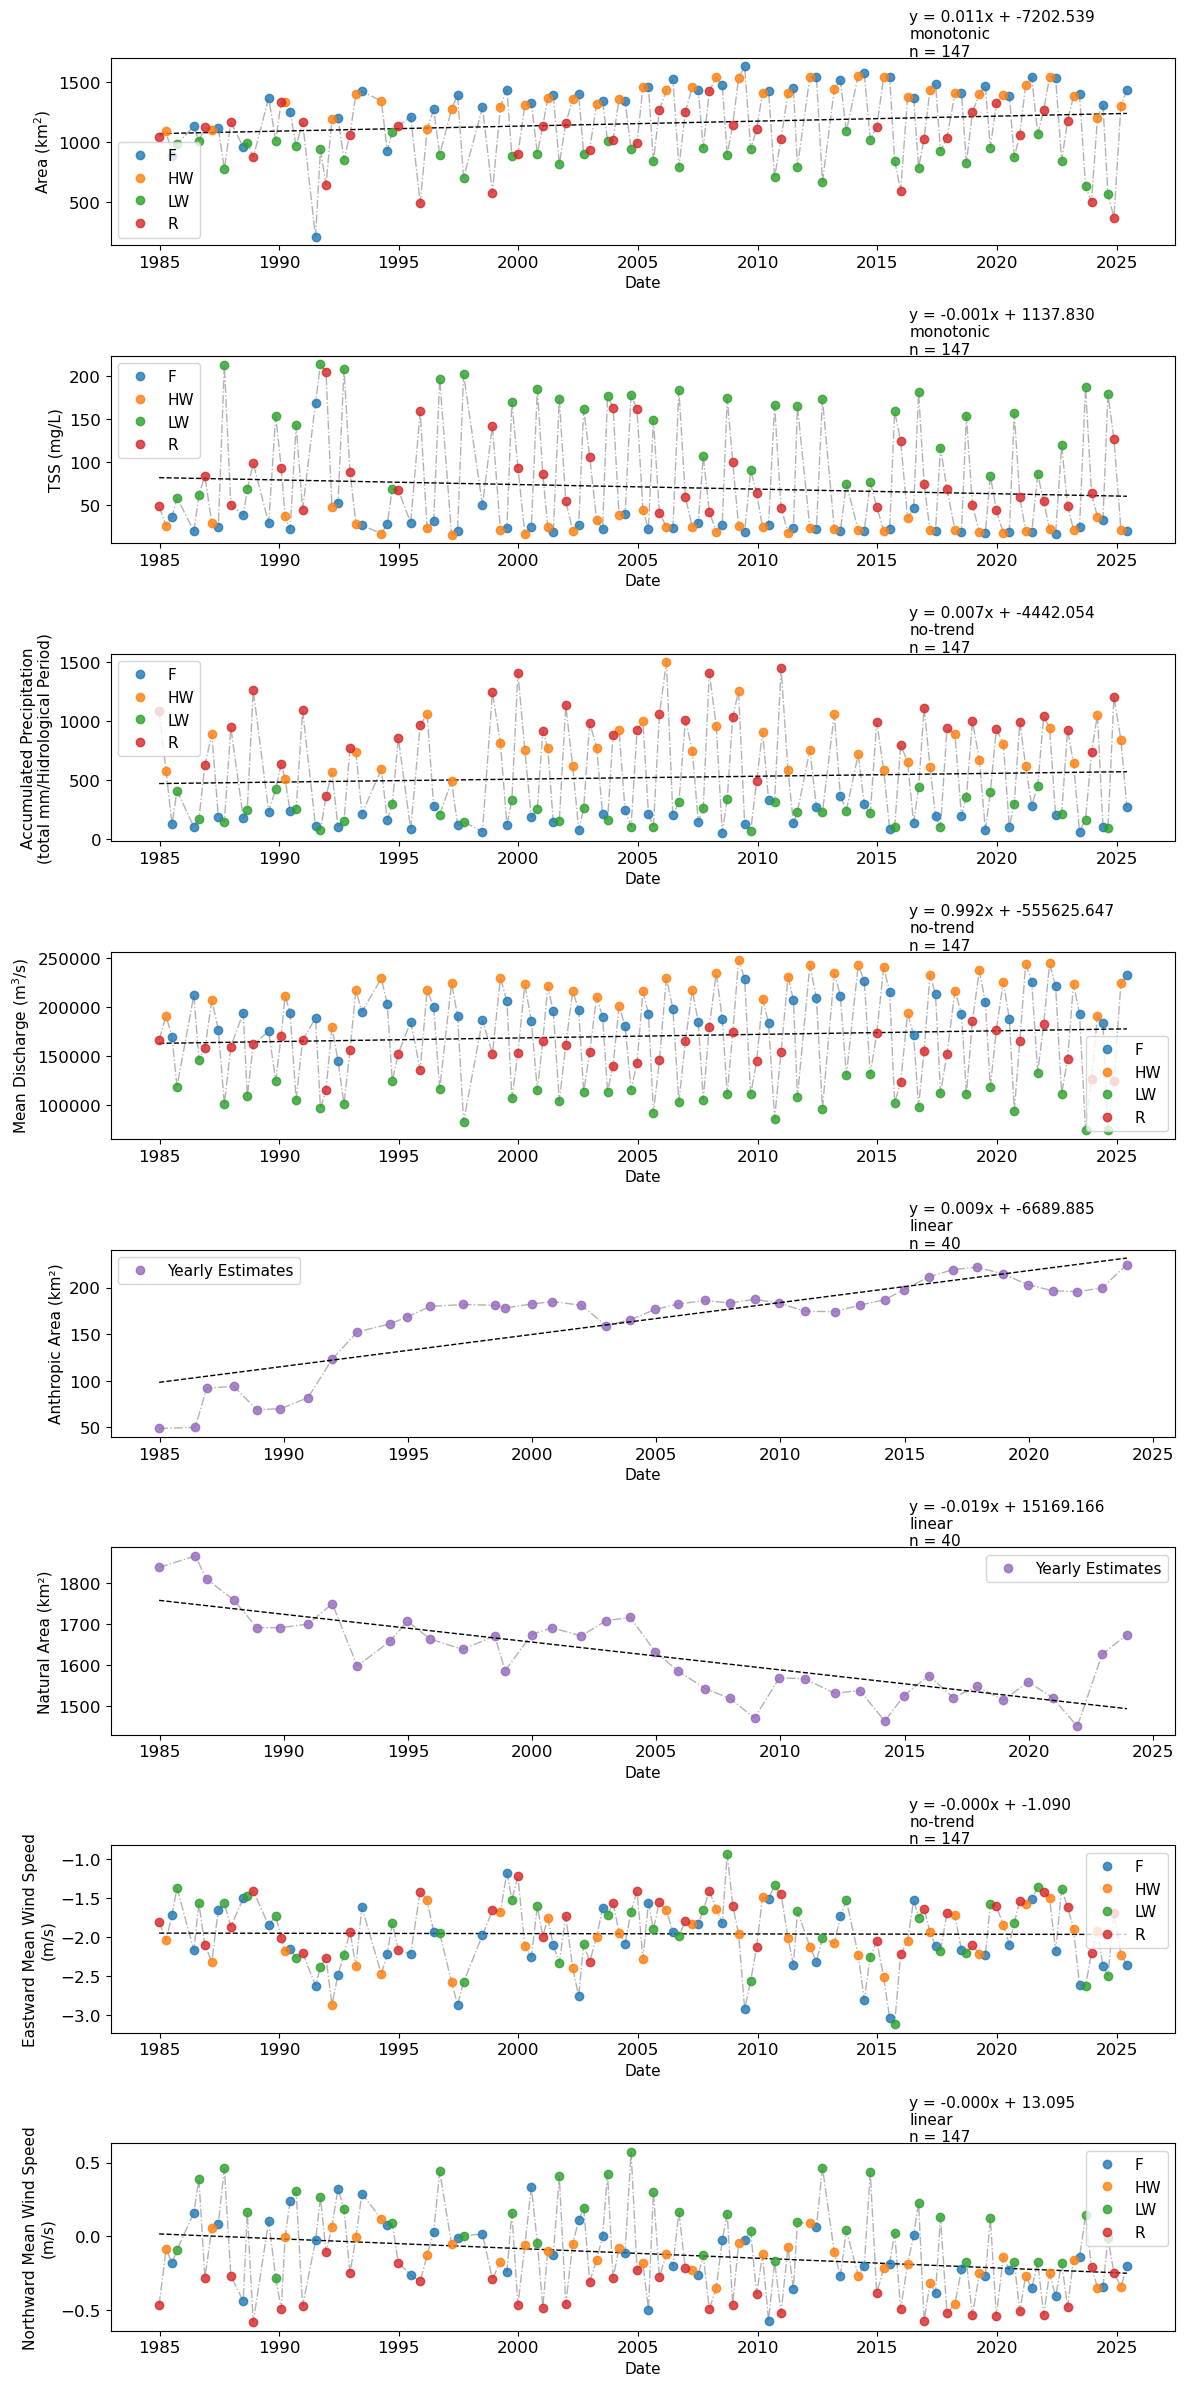

In [90]:
# Prepare and call plotting helper
watersheds = ["regional","local"]
for watershed in watersheds:
    # paths_var = sorted(glob.glob(os.path.join(data_dir,f"{watershed}*/filled*.csv")))
    paths_var = sorted(glob.glob(os.path.join(data_dir,f"*merged*{watershed}.csv")))
    paths_trend = sorted(glob.glob(os.path.join(data_dir,f"{watershed}*Watershed/trends/*al.csv")))
    # Call the cleaned, efficient plotting function. It will loop over paired files and show figures.
    prepare_time_series_plot(paths_var, paths_trend, dict_var, data_dir)